# Machine Learning Assignment (Polynomial Regression)

This notebook implements polynomial regression for VAR1 and VAR2, including data inspection, eda, model selection, final training, diagnostics, and test-set inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

In [2]:
# Loading data
train_var1 = pd.read_csv("Dataset/IMT2023555_train_var1.csv")
test_var1 = pd.read_csv("Dataset/IMT2023555_test_var1.csv")

train_var2 = pd.read_csv("Dataset/IMT2023555_train_var2.csv")
test_var2 = pd.read_csv("Dataset/IMT2023555_test_var2.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. Dataset Inspection and Validation

In [3]:
#Initial Dataset Inspection
datasets = {
    "VAR1 Train": train_var1,
    "VAR1 Test": test_var1,
    "VAR2 Train": train_var2,
    "VAR2 Test": test_var2
}

for name, df in datasets.items():
    print(name)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nFirst 5 rows:")
    display(df.head())
    print()

VAR1 Train
Shape: (1000, 7)
Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']

First 5 rows:


,x1,x2,x3,x4,x5,x6,y
0,-0.129656,0.100041,-0.683686,-1.000000,1.000000,1.000000,6.944284
1,0.670291,-1.000000,-0.594414,-0.080961,-1.000000,-1.000000,4.504368
2,-0.858342,0.538874,-1.000000,0.824375,0.149936,-0.403362,-0.271141
3,0.231969,0.681520,1.000000,1.000000,0.749791,-0.063300,-3.589001
4,-0.978277,-0.914562,0.608867,-0.672189,0.991487,0.522336,1.285541



VAR1 Test
Shape: (1000, 6)
Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

First 5 rows:


,x1,x2,x3,x4,x5,x6
0,0.918153,1.000000,1.000000,1.000000,0.879090,-1.000000
1,-0.355651,-1.000000,-0.816774,-0.600370,0.645933,-0.518338
2,-1.000000,0.573736,-0.145786,0.286548,-1.000000,-0.235250
3,0.222118,0.925009,1.000000,1.000000,0.594403,-1.000000
4,0.387160,0.684161,0.877487,0.265945,1.000000,-1.000000



VAR2 Train
Shape: (1000, 4)
Columns: ['x1', 'x2', 'x3', 'y']

First 5 rows:


,x1,x2,x3,y
0,-0.133516,-0.082212,-0.523733,0.620220
1,-1.000000,1.000000,0.930699,10.306113
2,1.000000,-1.000000,-0.286713,-9.952886
3,0.008912,0.147405,-0.143078,-0.164930
4,0.117216,1.000000,-1.000000,4.391439



VAR2 Test
Shape: (1000, 3)
Columns: ['x1', 'x2', 'x3']

First 5 rows:


,x1,x2,x3
0,0.140341,0.312902,0.968638
1,1.000000,-0.728585,-1.000000
2,0.781299,-0.145999,0.655323
3,0.261268,-1.000000,-0.186221
4,0.190208,-0.066386,1.000000


In [4]:
#Data Types and Structural Validation
for name, df in datasets.items():
    print(name)
    
    print("\nData types:")
    print(df.dtypes)
    
    print("\nNumber of rows:", df.shape[0])
    print("Number of columns:", df.shape[1])
    print("Shape:", df.shape)
    print()

VAR1 Train

Data types:
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
y     float64
dtype: object

Number of rows: 1000
Number of columns: 7
Shape: (1000, 7)

VAR1 Test

Data types:
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
dtype: object

Number of rows: 1000
Number of columns: 6
Shape: (1000, 6)

VAR2 Train

Data types:
x1    float64
x2    float64
x3    float64
y     float64
dtype: object

Number of rows: 1000
Number of columns: 4
Shape: (1000, 4)

VAR2 Test

Data types:
x1    float64
x2    float64
x3    float64
dtype: object

Number of rows: 1000
Number of columns: 3
Shape: (1000, 3)



In [5]:
#Missing Values and Duplicate Checks

for name, df in datasets.items():
    print(name)
    
    # Missing values
    print("\nMissing values:")
    print(df.isnull().sum())
    
    # Total missing values
    print("Total missing values:", df.isnull().sum().sum())
    
    # Duplicate rows
    print("Duplicate rows:", df.duplicated().sum())
    print()

VAR1 Train

Missing values:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
y     0
dtype: int64
Total missing values: 0
Duplicate rows: 0

VAR1 Test

Missing values:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
dtype: int64
Total missing values: 0
Duplicate rows: 6

VAR2 Train

Missing values:
x1    0
x2    0
x3    0
y     0
dtype: int64
Total missing values: 0
Duplicate rows: 0

VAR2 Test

Missing values:
x1    0
x2    0
x3    0
dtype: int64
Total missing values: 0
Duplicate rows: 7



In [6]:
#Descriptive Statistics

print("VAR1 TRAIN")
display(train_var1.describe())

print("\nVAR1 TEST")
display(test_var1.describe())

print("\nVAR2 TRAIN")
display(train_var2.describe())

print("\nVAR2 TEST")
display(test_var2.describe())

VAR1 TRAIN


,x1,x2,x3,x4,x5,x6,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.020107,-0.031860,-0.039200,0.011616,-0.025487,-0.020440,0.812705
std,0.709136,0.715385,0.715766,0.711716,0.720960,0.712473,3.208412
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-9.923569
25%,-0.631555,-0.725827,-0.717141,-0.646359,-0.756234,-0.694169,-1.113509
50%,0.020970,-0.056768,-0.024403,0.023649,-0.025856,-0.037408,0.713120
75%,0.708374,0.633124,0.606706,0.676418,0.623089,0.634202,2.873062
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.073484



VAR1 TEST


,x1,x2,x3,x4,x5,x6
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.016050,0.009140,0.018226,-0.027523,-0.003454,0.002371
std,0.838001,0.828991,0.817927,0.810866,0.817327,0.811412
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,-0.975646,-1.000000,-1.000000,-0.958856
50%,0.024795,0.024635,0.050096,-0.053143,-0.009039,-0.030076
75%,1.000000,1.000000,1.000000,0.955874,1.000000,0.978557
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



VAR2 TRAIN


,x1,x2,x3,y
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.026917,-0.004836,0.004569,2.154694
std,0.686322,0.672472,0.691972,6.629498
min,-1.000000,-1.000000,-1.000000,-29.810902
25%,-0.561692,-0.568779,-0.604764,-0.857991
50%,0.041290,-0.011260,0.000185,1.181507
75%,0.665774,0.549675,0.629275,4.879908
max,1.000000,1.000000,1.000000,40.027946



VAR2 TEST


,x1,x2,x3
count,1000.000000,1000.000000,1000.000000
mean,-0.000604,-0.031637,0.030185
std,0.652049,0.659967,0.663108
min,-1.000000,-1.000000,-1.000000
25%,-0.558986,-0.623488,-0.505298
50%,0.017012,-0.019749,0.014709
75%,0.511147,0.500881,0.602221
max,1.000000,1.000000,1.000000


## 3. Exploratory Data Analysis

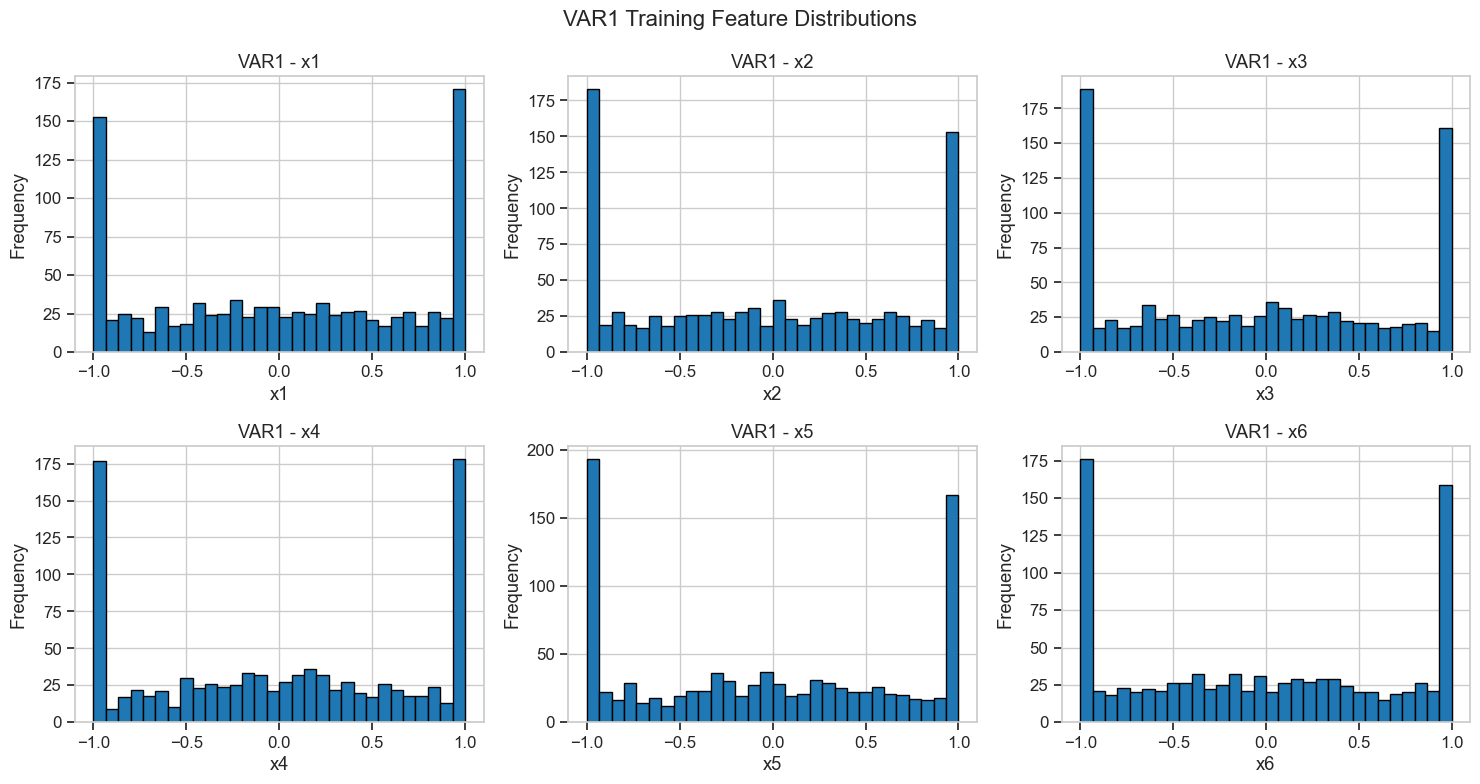

In [7]:
#VAR1 Feature Distributions

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate([f"x{i}" for i in range(1, 7)]):
    ax = axes[i // 3, i % 3]
    
    ax.hist(train_var1[feature], bins=30, edgecolor="black")
    ax.set_title(f"VAR1 - {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.suptitle("VAR1 Training Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

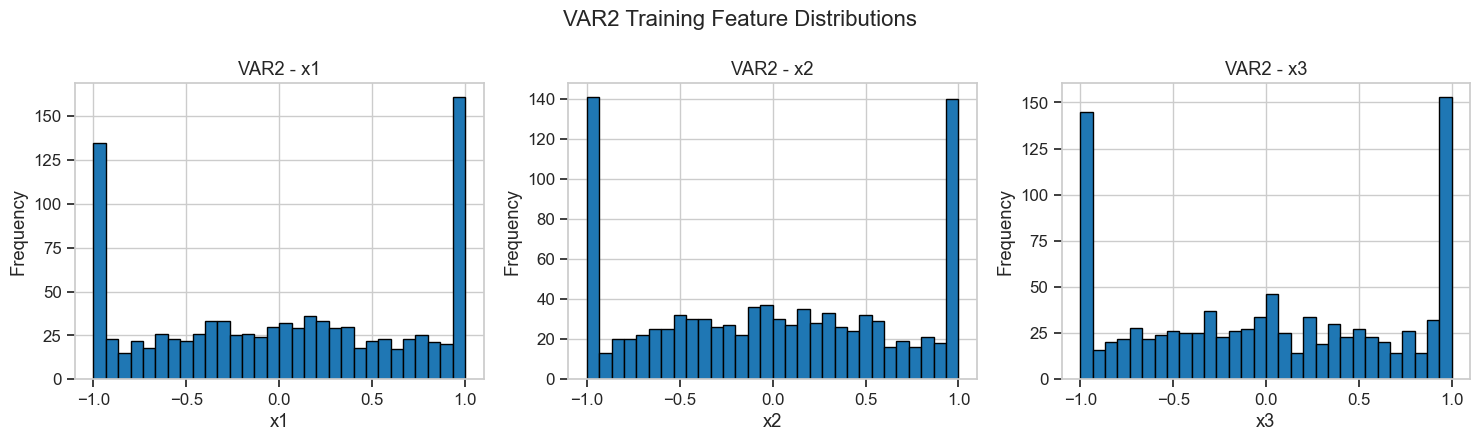

In [8]:
#VAR2 Feature Distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, feature in enumerate(["x1", "x2", "x3"]):
    ax = axes[i]
    
    ax.hist(train_var2[feature], bins=30, edgecolor="black")
    ax.set_title(f"VAR2 - {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.suptitle("VAR2 Training Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

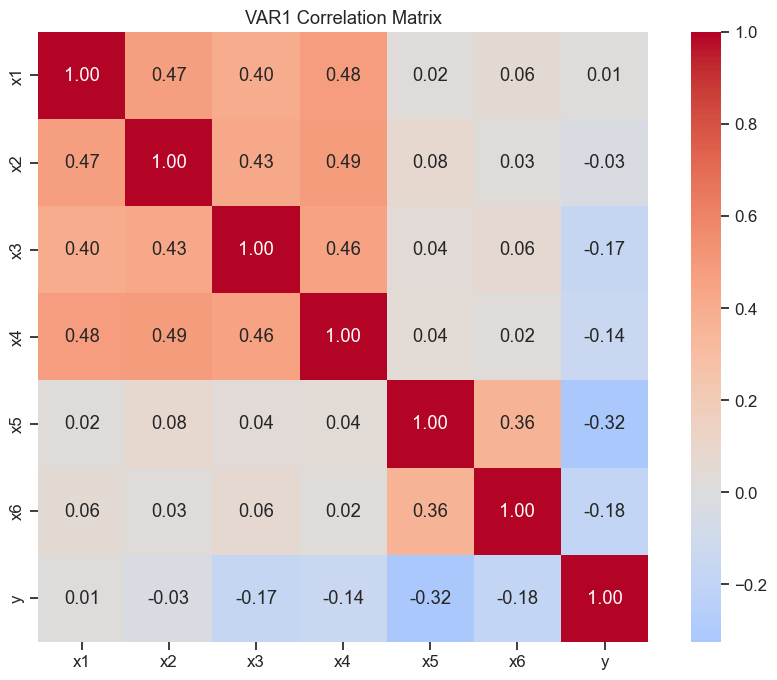

In [9]:
#VAR1 Correlation Analysis

corr_var1 = train_var1.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_var1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("VAR1 Correlation Matrix")
plt.tight_layout()
plt.show()

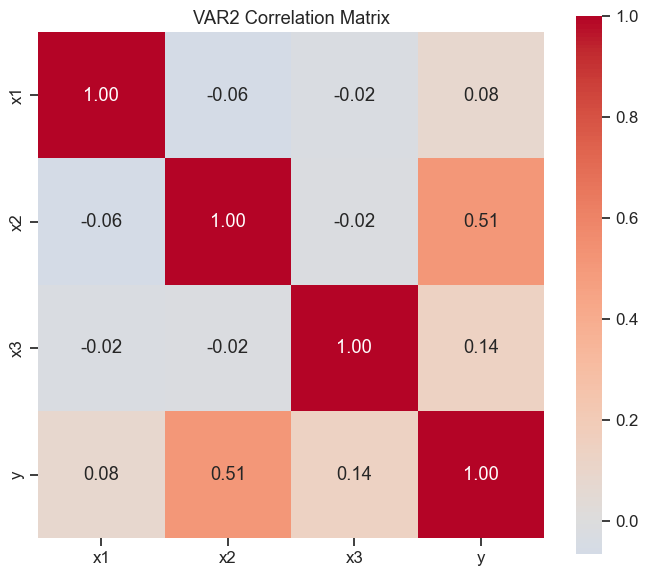

In [10]:
#VAR2 Correlation Analysis

corr_var2 = train_var2.corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_var2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("VAR2 Correlation Matrix")
plt.tight_layout()
plt.show()

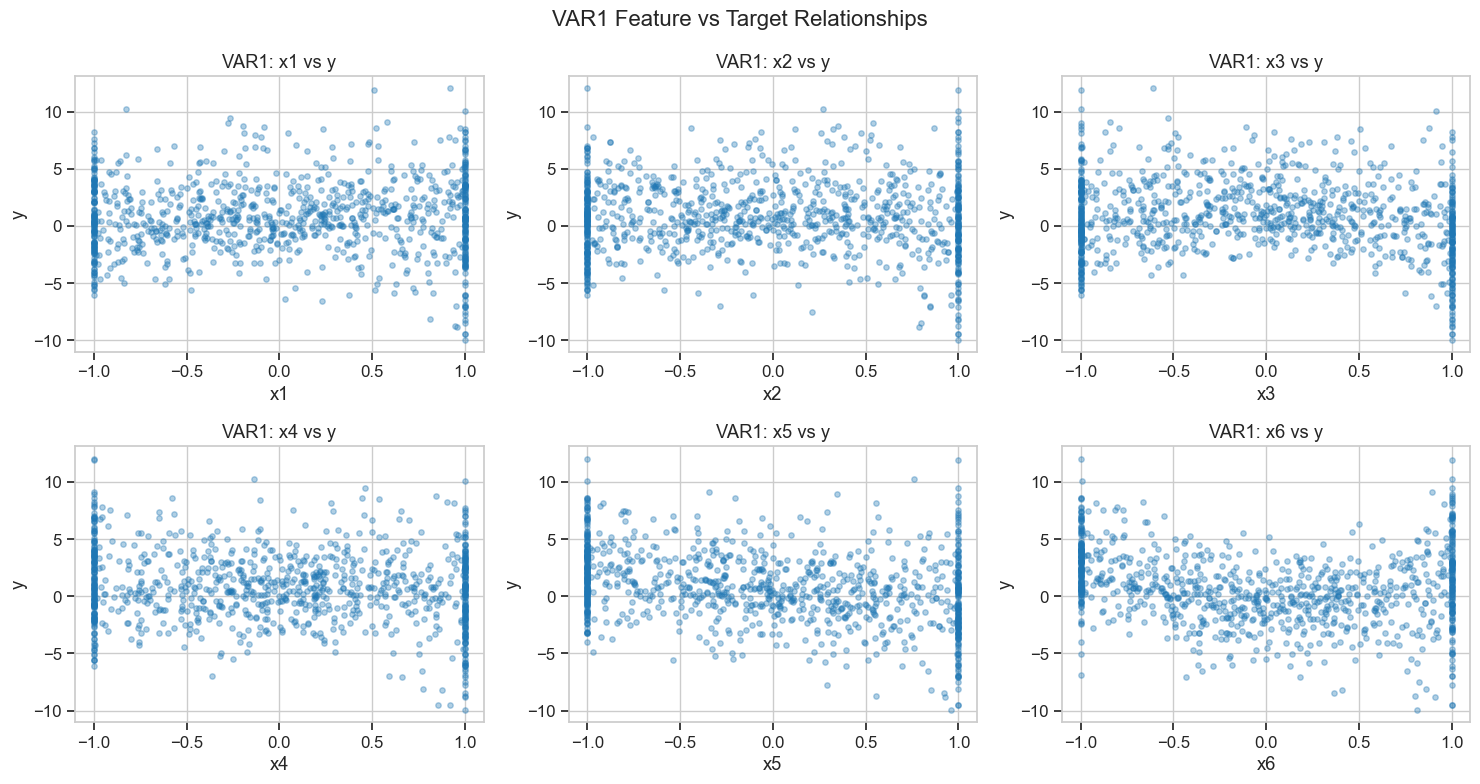

In [11]:
#VAR1 Feature vs Target Relationships

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_v1 = ["x1", "x2", "x3", "x4", "x5", "x6"]

for i, feature in enumerate(features_v1):
    ax = axes[i // 3, i % 3]
    
    ax.scatter(
        train_var1[feature],
        train_var1["y"],
        alpha=0.35,
        s=15
    )
    
    ax.set_title(f"VAR1: {feature} vs y")
    ax.set_xlabel(feature)
    ax.set_ylabel("y")

plt.suptitle("VAR1 Feature vs Target Relationships", fontsize=16)
plt.tight_layout()
plt.show()

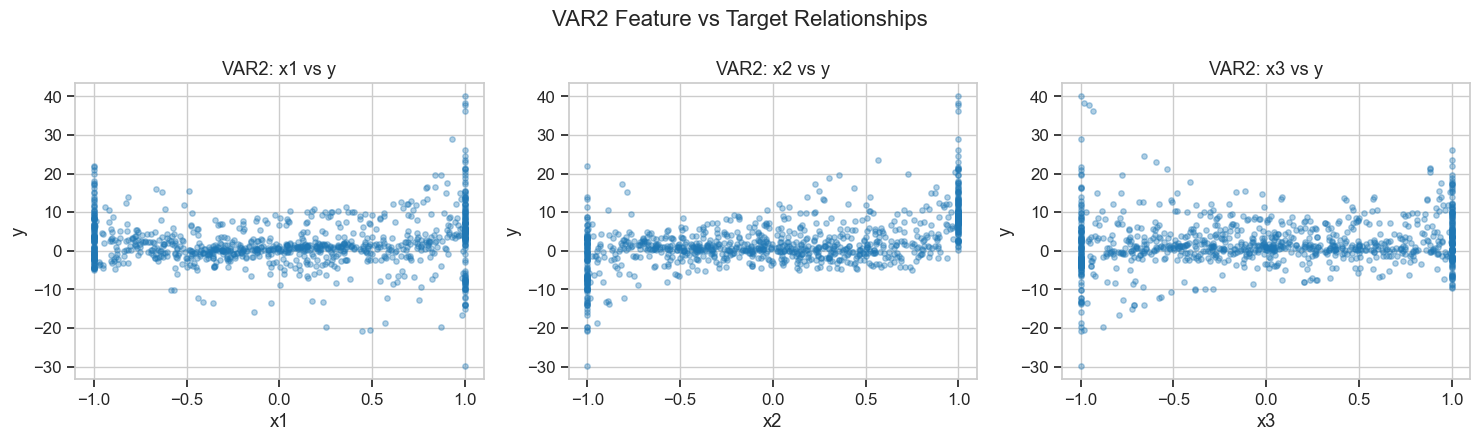

In [12]:
#VAR2 Feature vs Target Relationships

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

features_v2 = ["x1", "x2", "x3"]

for i, feature in enumerate(features_v2):
    ax = axes[i]
    
    ax.scatter(
        train_var2[feature],
        train_var2["y"],
        alpha=0.35,
        s=15
    )
    
    ax.set_title(f"VAR2: {feature} vs y")
    ax.set_xlabel(feature)
    ax.set_ylabel("y")

plt.suptitle("VAR2 Feature vs Target Relationships", fontsize=16)
plt.tight_layout()
plt.show()

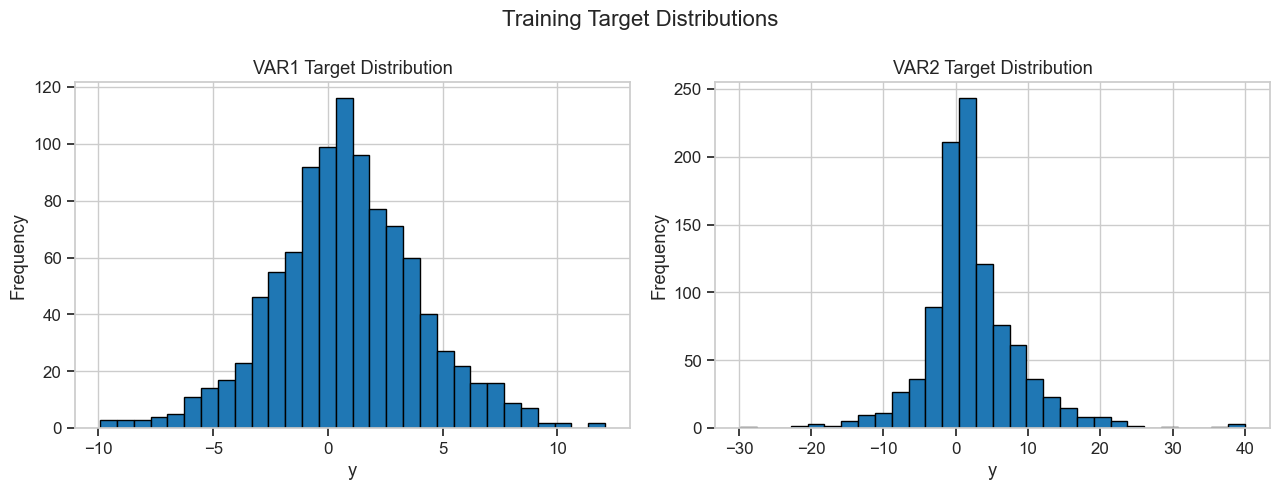

In [13]:
#Target Distributions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# VAR1 target
axes[0].hist(
    train_var1["y"],
    bins=30,
    edgecolor="black"
)
axes[0].set_title("VAR1 Target Distribution")
axes[0].set_xlabel("y")
axes[0].set_ylabel("Frequency")

# VAR2 target
axes[1].hist(
    train_var2["y"],
    bins=30,
    edgecolor="black"
)
axes[1].set_title("VAR2 Target Distribution")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Frequency")

plt.suptitle("Training Target Distributions", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Feature and Target Preparation

In [14]:
#Separate Features and Target

# VAR1
X_v1 = train_var1.drop(columns=["y"])
y_v1 = train_var1["y"]

# VAR2
X_v2 = train_var2.drop(columns=["y"])
y_v2 = train_var2["y"]

print("VAR1")
print("X shape:", X_v1.shape)
print("y shape:", y_v1.shape)

print("\nVAR2")
print("X shape:", X_v2.shape)
print("y shape:", y_v2.shape)

VAR1
X shape: (1000, 6)
y shape: (1000,)

VAR2
X shape: (1000, 3)
y shape: (1000,)


## 5. Baseline Linear Regression

In [15]:
#Baseline Linear Regression with 5-Fold Cross-Validation

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Linear regression model
linear_model = LinearRegression()

# Evaluate VAR1
cv_v1 = cross_validate(
    linear_model,
    X_v1,
    y_v1,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Evaluate VAR2
cv_v2 = cross_validate(
    linear_model,
    X_v2,
    y_v2,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Convert negative MSE to normal positive MSE
v1_train_mse = -cv_v1["train_mse"].mean()
v1_val_mse = -cv_v1["test_mse"].mean()
v1_train_r2 = cv_v1["train_r2"].mean()
v1_val_r2 = cv_v1["test_r2"].mean()

v2_train_mse = -cv_v2["train_mse"].mean()
v2_val_mse = -cv_v2["test_mse"].mean()
v2_train_r2 = cv_v2["train_r2"].mean()
v2_val_r2 = cv_v2["test_r2"].mean()

print("VAR1 - Linear Regression Baseline")
print(f"Train MSE: {v1_train_mse:.6f}")
print(f"Validation MSE: {v1_val_mse:.6f}")
print(f"Train R²: {v1_train_r2:.6f}")
print(f"Validation R²: {v1_val_r2:.6f}\n")


print("\nVAR2 - Linear Regression Baseline")
print(f"Train MSE: {v2_train_mse:.6f}")
print(f"Validation MSE: {v2_val_mse:.6f}")
print(f"Train R²: {v2_train_r2:.6f}")
print(f"Validation R²: {v2_val_r2:.6f}")

VAR1 - Linear Regression Baseline
Train MSE: 8.663552
Validation MSE: 8.846755
Train R²: 0.157281
Validation R²: 0.135799


VAR2 - Linear Regression Baseline
Train MSE: 30.826585
Validation MSE: 31.298461
Train R²: 0.297707
Validation R²: 0.284147


## 6. Polynomial Regression Setup

In [16]:
#Degree-2 Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# Degree-2 polynomial regression pipeline
poly2_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Evaluate VAR1
cv_poly2_v1 = cross_validate(
    poly2_model,
    X_v1,
    y_v1,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Evaluate VAR2
cv_poly2_v2 = cross_validate(
    poly2_model,
    X_v2,
    y_v2,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Convert negative MSE to positive MSE
poly2_v1_train_mse = -cv_poly2_v1["train_mse"].mean()
poly2_v1_val_mse = -cv_poly2_v1["test_mse"].mean()
poly2_v1_train_r2 = cv_poly2_v1["train_r2"].mean()
poly2_v1_val_r2 = cv_poly2_v1["test_r2"].mean()

poly2_v2_train_mse = -cv_poly2_v2["train_mse"].mean()
poly2_v2_val_mse = -cv_poly2_v2["test_mse"].mean()
poly2_v2_train_r2 = cv_poly2_v2["train_r2"].mean()
poly2_v2_val_r2 = cv_poly2_v2["test_r2"].mean()

# Print results
print("VAR1 - Degree 2 Polynomial Regression")
print(f"Train MSE: {poly2_v1_train_mse:.6f}")
print(f"Validation MSE: {poly2_v1_val_mse:.6f}")
print(f"Train R²: {poly2_v1_train_r2:.6f}")
print(f"Validation R²: {poly2_v1_val_r2:.6f}\n")



print("\nVAR2 - Degree 2 Polynomial Regression")
print(f"Train MSE: {poly2_v2_train_mse:.6f}")
print(f"Validation MSE: {poly2_v2_val_mse:.6f}")
print(f"Train R²: {poly2_v2_train_r2:.6f}")
print(f"Validation R²: {poly2_v2_val_r2:.6f}")

VAR1 - Degree 2 Polynomial Regression
Train MSE: 2.886458
Validation MSE: 3.119429
Train R²: 0.719023
Validation R²: 0.691851


VAR2 - Degree 2 Polynomial Regression
Train MSE: 18.770011
Validation MSE: 19.692349
Train R²: 0.572226
Validation R²: 0.546991


## 7. Polynomial Degree Search

In [17]:
#Polynomial Degree Search with 5-Fold Cross-Validation

def evaluate_polynomial_degrees(X, y, max_degree, dataset_name):
    
    results = []
    print(f"Evaluating {dataset_name}\n")
    
    for degree in range(1, max_degree + 1):
        
        # Polynomial regression pipeline
        model = Pipeline([
            ('poly', PolynomialFeatures(
                degree=degree,
                include_bias=False
            )),
            ('scaler', StandardScaler()),
            ('linear', LinearRegression())
        ])
        
        # 5-fold cross-validation
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=kf,
            scoring={
                'mse': 'neg_mean_squared_error',
                'r2': 'r2'
            },
            return_train_score=True,
            n_jobs=-1
        )
        
        # Convert negative MSE to positive MSE
        train_mse = -cv_results['train_mse'].mean()
        val_mse = -cv_results['test_mse'].mean()
        
        train_r2 = cv_results['train_r2'].mean()
        val_r2 = cv_results['test_r2'].mean()
        
        # Store results
        results.append({
            'degree': degree,
            'train_mse': train_mse,
            'val_mse': val_mse,
            'train_r2': train_r2,
            'val_r2': val_r2
        })
        
        print(
            f"Degree {degree:2d} | "
            f"Train MSE: {train_mse:.6f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Train R²: {train_r2:.6f} | "
            f"Val R²: {val_r2:.6f}"
        )
    
    return pd.DataFrame(results)

In [18]:
#Degree Search for VAR1

results_v1 = evaluate_polynomial_degrees(
    X_v1,
    y_v1,
    max_degree=10,
    dataset_name="VAR1"
)

Evaluating VAR1

Degree  1 | Train MSE: 8.663552 | Val MSE: 8.846755 | Train R²: 0.157281 | Val R²: 0.135799
Degree  2 | Train MSE: 2.886458 | Val MSE: 3.119429 | Train R²: 0.719023 | Val R²: 0.691851
Degree  3 | Train MSE: 0.766861 | Val MSE: 0.959368 | Train R²: 0.925366 | Val R²: 0.905402
Degree  4 | Train MSE: 0.357905 | Val MSE: 0.835083 | Train R²: 0.965190 | Val R²: 0.918600
Degree  5 | Train MSE: 0.113400 | Val MSE: 1.650592 | Train R²: 0.988966 | Val R²: 0.838367
Degree  6 | Train MSE: 0.000000 | Val MSE: 65.360311 | Train R²: 1.000000 | Val R²: -5.348039
Degree  7 | Train MSE: 0.000000 | Val MSE: 6.989358 | Train R²: 1.000000 | Val R²: 0.320460
Degree  8 | Train MSE: 0.000000 | Val MSE: 4.312263 | Train R²: 1.000000 | Val R²: 0.584724
Degree  9 | Train MSE: 0.000000 | Val MSE: 3.923206 | Train R²: 1.000000 | Val R²: 0.618000
Degree 10 | Train MSE: 0.000000 | Val MSE: 4.346910 | Train R²: 1.000000 | Val R²: 0.581885


In [19]:
#Degree Search for VAR2

results_v2 = evaluate_polynomial_degrees(
    X_v2,
    y_v2,
    max_degree=20,
    dataset_name="VAR2"
)

Evaluating VAR2

Degree  1 | Train MSE: 30.826585 | Val MSE: 31.298461 | Train R²: 0.297707 | Val R²: 0.284147
Degree  2 | Train MSE: 18.770011 | Val MSE: 19.692349 | Train R²: 0.572226 | Val R²: 0.546991
Degree  3 | Train MSE: 9.982347 | Val MSE: 11.007994 | Train R²: 0.772541 | Val R²: 0.747709
Degree  4 | Train MSE: 3.342598 | Val MSE: 3.981172 | Train R²: 0.923789 | Val R²: 0.907858
Degree  5 | Train MSE: 1.246710 | Val MSE: 1.662498 | Train R²: 0.971591 | Val R²: 0.961827
Degree  6 | Train MSE: 0.453953 | Val MSE: 0.646651 | Train R²: 0.989655 | Val R²: 0.985112
Degree  7 | Train MSE: 0.229972 | Val MSE: 0.338495 | Train R²: 0.994757 | Val R²: 0.992181
Degree  8 | Train MSE: 0.163989 | Val MSE: 0.294832 | Train R²: 0.996260 | Val R²: 0.993182
Degree  9 | Train MSE: 0.143537 | Val MSE: 0.305811 | Train R²: 0.996725 | Val R²: 0.992891
Degree 10 | Train MSE: 0.125121 | Val MSE: 0.383388 | Train R²: 0.997145 | Val R²: 0.991057
Degree 11 | Train MSE: 0.106542 | Val MSE: 0.524594 | Trai

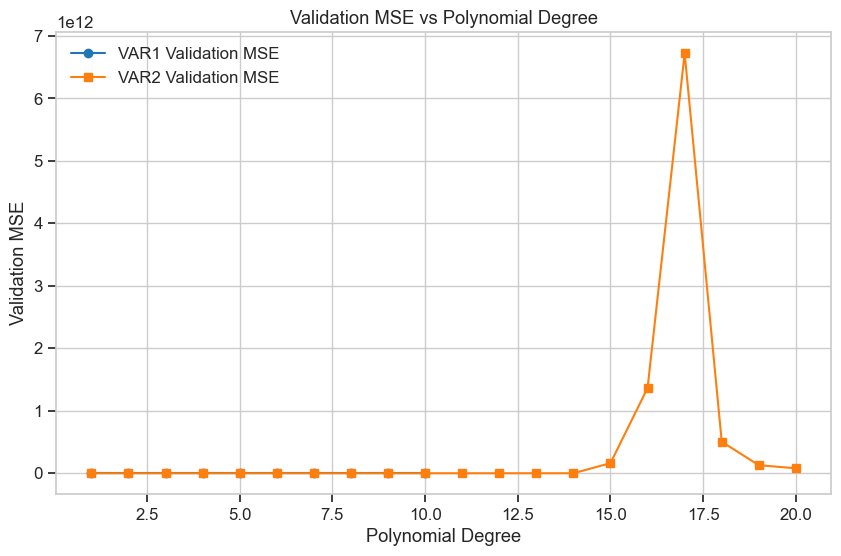

In [20]:
#Validation MSE vs Polynomial Degree

plt.figure(figsize=(10, 6))

plt.plot(
    results_v1['degree'],
    results_v1['val_mse'],
    marker='o',
    label='VAR1 Validation MSE'
)

plt.plot(
    results_v2['degree'],
    results_v2['val_mse'],
    marker='s',
    label='VAR2 Validation MSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('Validation MSE')
plt.title('Validation MSE vs Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
best_degree_v1 = results_v1.loc[
    results_v1['val_mse'].idxmin(),
    'degree'
]

best_degree_v2 = results_v2.loc[
    results_v2['val_mse'].idxmin(),
    'degree'
]

print("Best VAR1 degree:", best_degree_v1)
print("Best VAR2 degree:", best_degree_v2)

Best VAR1 degree: 4
Best VAR2 degree: 8


In [22]:
#Inspect all polynomial degree results

print("VAR1 DEGREE RESULTS\n")
display(
    results_v1.round(6)
)

print("\nVAR2 DEGREE RESULTS")
display(
    results_v2.round(6)
)

VAR1 DEGREE RESULTS



,degree,train_mse,val_mse,train_r2,val_r2
0,1,8.663552,8.846755,0.157281,0.135799
1,2,2.886458,3.119429,0.719023,0.691851
2,3,0.766861,0.959368,0.925366,0.905402
3,4,0.357905,0.835083,0.965190,0.918600
4,5,0.113400,1.650592,0.988966,0.838367
5,6,0.000000,65.360311,1.000000,-5.348039
6,7,0.000000,6.989358,1.000000,0.320460
7,8,0.000000,4.312263,1.000000,0.584724
8,9,0.000000,3.923206,1.000000,0.618000
9,10,0.000000,4.346910,1.000000,0.581885



VAR2 DEGREE RESULTS


,degree,train_mse,val_mse,train_r2,val_r2
0,1,30.826585,3.129846e+01,0.297707,2.841470e-01
1,2,18.770011,1.969235e+01,0.572226,5.469910e-01
2,3,9.982347,1.100799e+01,0.772541,7.477090e-01
3,4,3.342598,3.981172e+00,0.923789,9.078580e-01
4,5,1.246710,1.662498e+00,0.971591,9.618270e-01
5,6,0.453953,6.466510e-01,0.989655,9.851120e-01
6,7,0.229972,3.384950e-01,0.994757,9.921810e-01
7,8,0.163989,2.948320e-01,0.996260,9.931820e-01
8,9,0.143537,3.058110e-01,0.996725,9.928910e-01
9,10,0.125121,3.833880e-01,0.997145,9.910570e-01


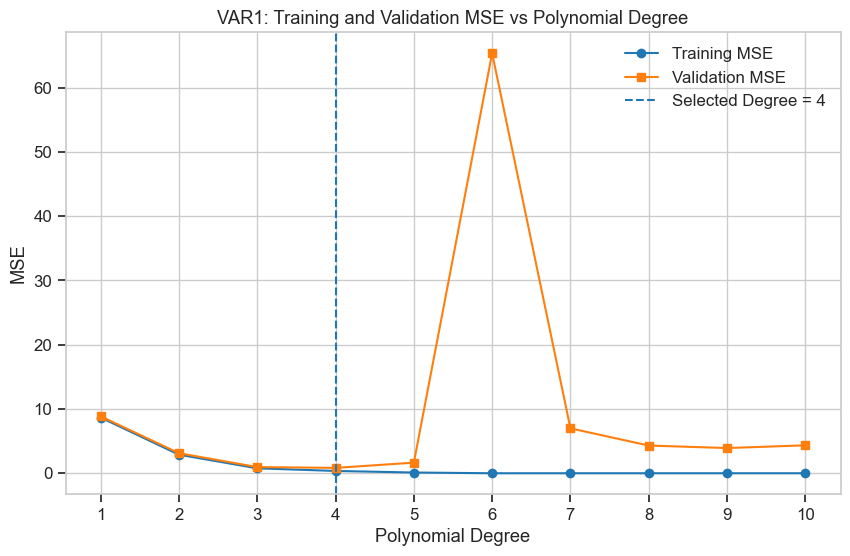

In [23]:
#VAR1 Polynomial Degree Learning Curve

plt.figure(figsize=(10, 6))

plt.plot(
    results_v1['degree'],
    results_v1['train_mse'],
    marker='o',
    label='Training MSE'
)

plt.plot(
    results_v1['degree'],
    results_v1['val_mse'],
    marker='s',
    label='Validation MSE'
)

plt.axvline(
    best_degree_v1,
    linestyle='--',
    label=f'Selected Degree = {best_degree_v1}'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('VAR1: Training and Validation MSE vs Polynomial Degree')
plt.xticks(results_v1['degree'])
plt.legend()
plt.grid(True)
plt.show()

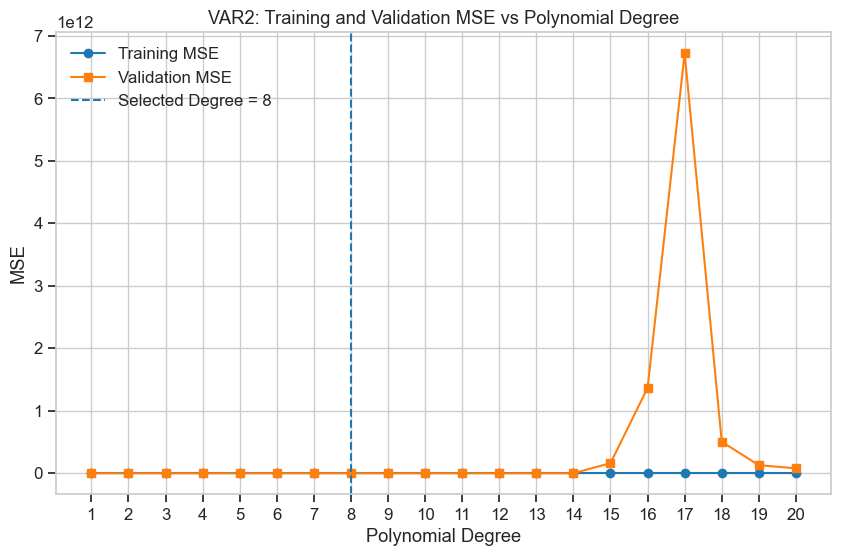

In [24]:
#VAR2 Polynomial Degree Learning Curve

plt.figure(figsize=(10, 6))

plt.plot(
    results_v2['degree'],
    results_v2['train_mse'],
    marker='o',
    label='Training MSE'
)

plt.plot(
    results_v2['degree'],
    results_v2['val_mse'],
    marker='s',
    label='Validation MSE'
)

plt.axvline(
    best_degree_v2,
    linestyle='--',
    label=f'Selected Degree = {best_degree_v2}'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('VAR2: Training and Validation MSE vs Polynomial Degree')
plt.xticks(results_v2['degree'])
plt.legend()
plt.grid(True)
plt.show()

## 8. Feature Subset and Degree Search

In [25]:
# EXHAUSTIVE FEATURE SUBSET + DEGREE SEARCH

from itertools import combinations
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
import pandas as pd
import numpy as np

#Cross-validation setup

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Function for exhaustive search

def exhaustive_polynomial_search(X, y, feature_names, max_degree):
    
    results = []
    
    # Generate every non-empty feature subset
    for subset_size in range(1, len(feature_names) + 1):
        
        for subset in combinations(feature_names, subset_size):
            
            subset = list(subset)
            
            X_subset = X[subset]
            
            # Test every polynomial degree
            for degree in range(1, max_degree + 1):
                
                # Pipeline:
                # PolynomialFeatures -> StandardScaler -> LinearRegression
                model = Pipeline([
                    (
                        "poly",
                        PolynomialFeatures(
                            degree=degree,
                            include_bias=False
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    ),
                    (
                        "linear",
                        LinearRegression()
                    )
                ])
                
                cv_results = cross_validate(
                    model,
                    X_subset,
                    y,
                    cv=kf,
                    scoring={
                        "mse": "neg_mean_squared_error",
                        "r2": "r2"
                    },
                    return_train_score=True,
                    n_jobs=-1
                )
                
                train_mse = -cv_results["train_mse"].mean()
                val_mse = -cv_results["test_mse"].mean()
                
                train_r2 = cv_results["train_r2"].mean()
                val_r2 = cv_results["test_r2"].mean()
                
                results.append({
                    "features": ", ".join(subset),
                    "n_features": len(subset),
                    "degree": degree,
                    "train_mse": train_mse,
                    "val_mse": val_mse,
                    "train_r2": train_r2,
                    "val_r2": val_r2
                })
    
    return pd.DataFrame(results)

#VAR1 exhaustive search
print("STARTING VAR1 EXHAUSTIVE SEARCH\n")

results_v1_feature_degree = exhaustive_polynomial_search(
    X=X_v1,
    y=y_v1,
    feature_names=list(X_v1.columns),
    max_degree=10
)

print("\nVAR1 search completed.")
print("Number of configurations tested:",
      len(results_v1_feature_degree))

#VAR2 exhaustive search

print("\nSTARTING VAR2 EXHAUSTIVE SEARCH\n")

results_v2_feature_degree = exhaustive_polynomial_search(
    X=X_v2,
    y=y_v2,
    feature_names=list(X_v2.columns),
    max_degree=20
)

print("\nVAR2 search completed.")
print("Number of configurations tested:",
      len(results_v2_feature_degree))

# Sort by validation MSE

results_v1_feature_degree = (
    results_v1_feature_degree
    .sort_values("val_mse")
    .reset_index(drop=True)
)

results_v2_feature_degree = (
    results_v2_feature_degree
    .sort_values("val_mse")
    .reset_index(drop=True)
)

# 6. Display best configurations

print("\nBEST VAR1 CONFIGURATIONS\n")

display(
    results_v1_feature_degree.head(10)
)

print("\nBEST VAR2 CONFIGURATIONS\n")

display(
    results_v2_feature_degree.head(10)
)

STARTING VAR1 EXHAUSTIVE SEARCH


VAR1 search completed.
Number of configurations tested: 630

STARTING VAR2 EXHAUSTIVE SEARCH


VAR2 search completed.
Number of configurations tested: 140

BEST VAR1 CONFIGURATIONS



,features,n_features,degree,train_mse,val_mse,train_r2,val_r2
0,"x1, x2, x3, x4, x5, x6",6,4,0.357905,0.835083,0.965190,0.918600
1,"x1, x2, x3, x4, x5, x6",6,3,0.766861,0.959368,0.925366,0.905402
2,"x1, x2, x3, x4, x5, x6",6,5,0.113400,1.650592,0.988966,0.838367
3,"x1, x2, x3, x5, x6",5,3,1.493302,1.798126,0.854636,0.822264
4,"x1, x2, x3, x5, x6",5,4,1.146813,1.858439,0.888328,0.816134
5,"x1, x2, x3, x5, x6",5,5,0.806540,2.090612,0.921497,0.793662
6,"x1, x3, x4, x5, x6",5,3,2.316865,2.723905,0.774584,0.732767
7,"x1, x3, x4, x5, x6",5,4,1.963317,2.943538,0.808996,0.712135
8,"x2, x3, x4, x5, x6",5,3,2.638499,3.033264,0.743257,0.701425
9,"x1, x2, x3, x4, x5, x6",6,2,2.886458,3.119429,0.719023,0.691851



BEST VAR2 CONFIGURATIONS



,features,n_features,degree,train_mse,val_mse,train_r2,val_r2
0,"x1, x2, x3",3,8,0.163989,0.294832,0.996260,0.993182
1,"x1, x2, x3",3,9,0.143537,0.305811,0.996725,0.992891
2,"x1, x2, x3",3,7,0.229972,0.338495,0.994757,0.992181
3,"x1, x2, x3",3,10,0.125121,0.383388,0.997145,0.991057
4,"x1, x2, x3",3,11,0.106542,0.524594,0.997567,0.987739
5,"x1, x2, x3",3,6,0.453953,0.646651,0.989655,0.985112
6,"x1, x2, x3",3,12,0.085919,1.574988,0.998038,0.964635
7,"x1, x2, x3",3,5,1.246710,1.662498,0.971591,0.961827
8,"x1, x2, x3",3,4,3.342598,3.981172,0.923789,0.907858
9,"x1, x2, x3",3,13,0.060677,8.795909,0.998615,0.796611


## 9. Final Degree Selection and Stability Check

In [26]:
# NEARBY-DEGREE STABILITY CHECK

# VAR1: Compare degrees 3, 4, and 5
# using all six features

var1_features = "x1, x2, x3, x4, x5, x6"

var1_nearby = results_v1_feature_degree[
    (results_v1_feature_degree["features"] == var1_features) &
    (results_v1_feature_degree["degree"].isin([3, 4, 5]))
].sort_values("degree")


print("VAR1: NEARBY DEGREE COMPARISON")


display(
    var1_nearby[
        [
            "features",
            "degree",
            "train_mse",
            "val_mse",
            "train_r2",
            "val_r2"
        ]
    ]
)

# VAR2: Compare degrees 7, 8, and 9
# using all three features

var2_features = "x1, x2, x3"

var2_nearby = results_v2_feature_degree[
    (results_v2_feature_degree["features"] == var2_features) &
    (results_v2_feature_degree["degree"].isin([7, 8, 9]))
].sort_values("degree")

print("\nVAR2: NEARBY DEGREE COMPARISON\n")

display(
    var2_nearby[
        [
            "features",
            "degree",
            "train_mse",
            "val_mse",
            "train_r2",
            "val_r2"
        ]
    ]
)


# Identify selected degrees

selected_degree_v1 = (
    var1_nearby.loc[
        var1_nearby["val_mse"].idxmin(),
        "degree"
    ]
)

selected_degree_v2 = (
    var2_nearby.loc[
        var2_nearby["val_mse"].idxmin(),
        "degree"
    ]
)

print("\nSELECTED DEGREES FROM NEARBY COMPARISON\n")

print("VAR1 selected degree:", selected_degree_v1)
print("VAR2 selected degree:", selected_degree_v2)

VAR1: NEARBY DEGREE COMPARISON


,features,degree,train_mse,val_mse,train_r2,val_r2
1,"x1, x2, x3, x4, x5, x6",3,0.766861,0.959368,0.925366,0.905402
0,"x1, x2, x3, x4, x5, x6",4,0.357905,0.835083,0.965190,0.918600
2,"x1, x2, x3, x4, x5, x6",5,0.113400,1.650592,0.988966,0.838367



VAR2: NEARBY DEGREE COMPARISON



,features,degree,train_mse,val_mse,train_r2,val_r2
2,"x1, x2, x3",7,0.229972,0.338495,0.994757,0.992181
0,"x1, x2, x3",8,0.163989,0.294832,0.996260,0.993182
1,"x1, x2, x3",9,0.143537,0.305811,0.996725,0.992891



SELECTED DEGREES FROM NEARBY COMPARISON

VAR1 selected degree: 4
VAR2 selected degree: 8


## 10. Final Model Training

In [27]:
#FINAL MODEL TRAINING

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

# Final VAR1 model

final_model_v1 = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=best_degree_v1,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

# Fit on the complete VAR1 training dataset
final_model_v1.fit(X_v1, y_v1)



# Final VAR2 model


final_model_v2 = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=best_degree_v2,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

# Fit on the complete VAR2 training dataset
final_model_v2.fit(X_v2, y_v2)



print("FINAL MODEL TRAINING COMPLETE")


print("\nVAR1")
print("Features: x1, x2, x3, x4, x5, x6")
#print("Polynomial degree: 4")
print("Polynomial degree:", best_degree_v1)
print("Training samples:", len(X_v1))

print("\nVAR2")
print("Features: x1, x2, x3")
#print("Polynomial degree: 8")
print("Polynomial degree:", best_degree_v2)
print("Training samples:", len(X_v2))

FINAL MODEL TRAINING COMPLETE

VAR1
Features: x1, x2, x3, x4, x5, x6
Polynomial degree: 4
Training samples: 1000

VAR2
Features: x1, x2, x3
Polynomial degree: 8
Training samples: 1000


## 11. Final Model Diagnostics

In [28]:
#FINAL MODEL DIAGNOSTICS

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# VAR1 predictions and residuals

y_pred_train_v1 = final_model_v1.predict(X_v1)

residuals_v1 = y_v1 - y_pred_train_v1

train_mse_v1 = mean_squared_error(y_v1, y_pred_train_v1)
train_r2_v1 = r2_score(y_v1, y_pred_train_v1)

rmse_v1 = np.sqrt(train_mse_v1)

# VAR2 predictions and residuals

y_pred_train_v2 = final_model_v2.predict(X_v2)

residuals_v2 = y_v2 - y_pred_train_v2

train_mse_v2 = mean_squared_error(y_v2, y_pred_train_v2)
train_r2_v2 = r2_score(y_v2, y_pred_train_v2)

rmse_v2 = np.sqrt(train_mse_v2)


# Print results

print("FINAL MODEL TRAINING DIAGNOSTICS")


print("\nVAR1")
print("-" * 30)
print(f"Training MSE : {train_mse_v1:.6f}")
print(f"Training RMSE: {rmse_v1:.6f}")
print(f"Training R²  : {train_r2_v1:.6f}")

print("\nVAR2")
print("-" * 30)
print(f"Training MSE : {train_mse_v2:.6f}")
print(f"Training RMSE: {rmse_v2:.6f}")
print(f"Training R²  : {train_r2_v2:.6f}")

FINAL MODEL TRAINING DIAGNOSTICS

VAR1
------------------------------
Training MSE : 0.388911
Training RMSE: 0.623627
Training R²  : 0.962182

VAR2
------------------------------
Training MSE : 0.173530
Training RMSE: 0.416569
Training R²  : 0.996048


## 12. Residual Diagnostics

In [29]:
#RESIDUAL ANALYSIS
# Basic residual statistics

print("VAR1 RESIDUAL STATISTICS\n")

print(f"Mean residual      : {np.mean(residuals_v1):.6f}")
print(f"Std residual       : {np.std(residuals_v1):.6f}")
print(f"Minimum residual   : {np.min(residuals_v1):.6f}")
print(f"Maximum residual   : {np.max(residuals_v1):.6f}")
print(f"Median residual    : {np.median(residuals_v1):.6f}")

print("\nVAR2 RESIDUAL STATISTICS")


print(f"Mean residual      : {np.mean(residuals_v2):.6f}")
print(f"Std residual       : {np.std(residuals_v2):.6f}")
print(f"Minimum residual   : {np.min(residuals_v2):.6f}")
print(f"Maximum residual   : {np.max(residuals_v2):.6f}")
print(f"Median residual    : {np.median(residuals_v2):.6f}")

VAR1 RESIDUAL STATISTICS

Mean residual      : 0.000000
Std residual       : 0.623627
Minimum residual   : -2.047744
Maximum residual   : 2.415179
Median residual    : -0.008255

VAR2 RESIDUAL STATISTICS
Mean residual      : -0.000000
Std residual       : 0.416569
Minimum residual   : -1.454951
Maximum residual   : 1.730739
Median residual    : -0.000916


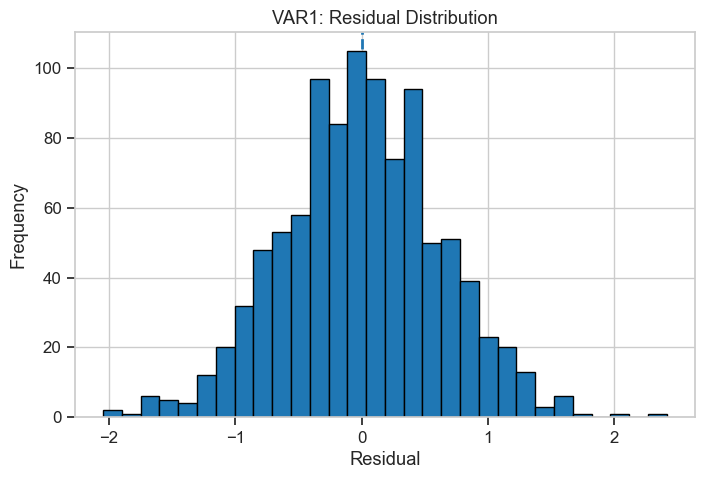

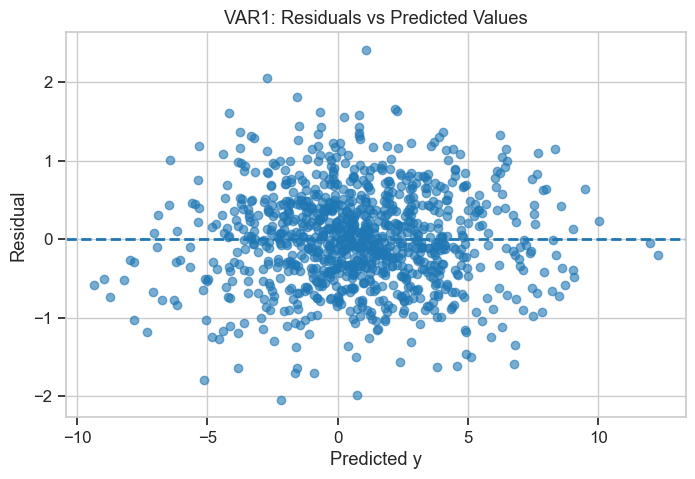

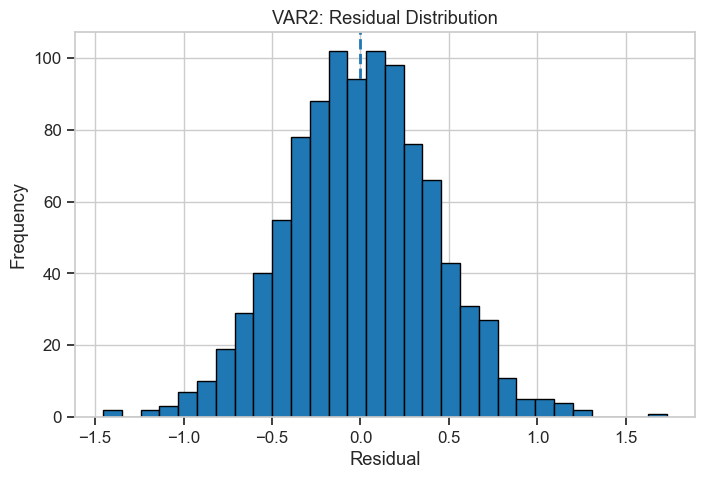

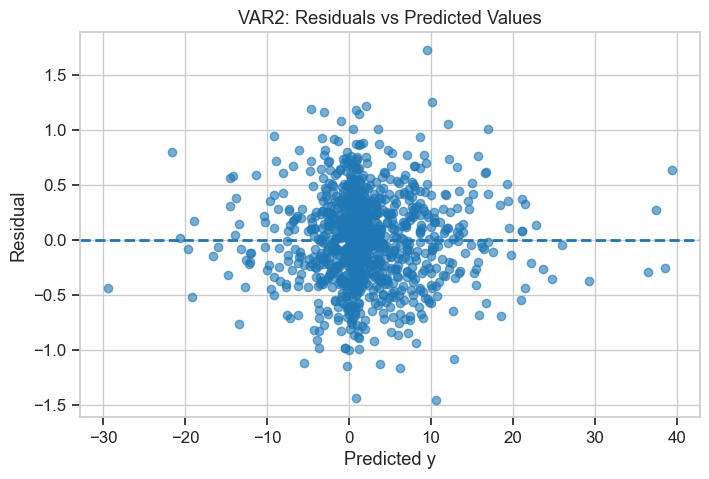

In [30]:
#RESIDUAL DIAGNOSTIC PLOTS

# VAR1: Residual distribution

plt.figure(figsize=(8, 5))

plt.hist(
    residuals_v1,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("VAR1: Residual Distribution")

plt.show()



# VAR1: Residuals vs predicted


plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_train_v1,
    residuals_v1,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted y")
plt.ylabel("Residual")
plt.title("VAR1: Residuals vs Predicted Values")

plt.show()



# VAR2: Residual distribution


plt.figure(figsize=(8, 5))

plt.hist(
    residuals_v2,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("VAR2: Residual Distribution")

plt.show()



# VAR2: Residuals vs predicted


plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_train_v2,
    residuals_v2,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted y")
plt.ylabel("Residual")
plt.title("VAR2: Residuals vs Predicted Values")

plt.show()

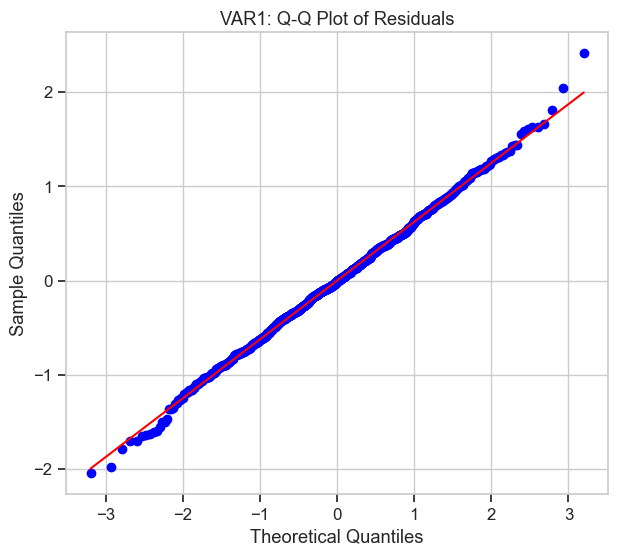

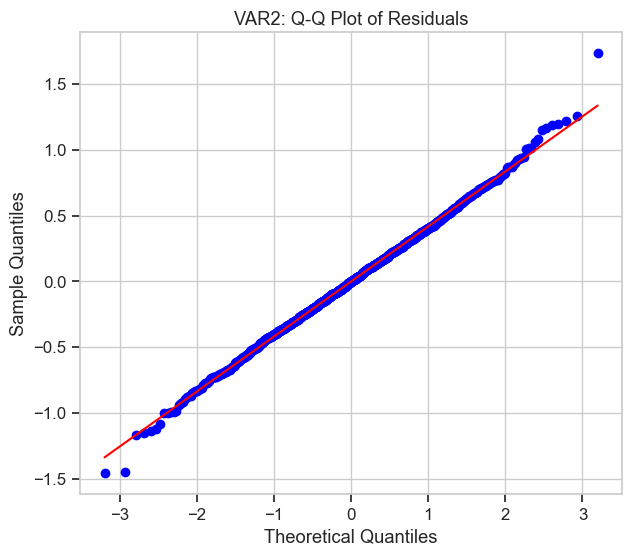

In [31]:
#Q-Q PLOTS

import scipy.stats as stats

# VAR1 Q-Q Plot

plt.figure(figsize=(7, 6))

stats.probplot(
    residuals_v1,
    dist="norm",
    plot=plt
)

plt.title("VAR1: Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)

plt.show()

# VAR2 Q-Q Plot


plt.figure(figsize=(7, 6))

stats.probplot(
    residuals_v2,
    dist="norm",
    plot=plt
)

plt.title("VAR2: Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)

plt.show()

## 13. Test-Set Inference

In [32]:
#FINAL TEST PREDICTIONS

print("GENERATING FINAL TEST PREDICTIONS\n")

# VAR1

y_test_pred_v1 = final_model_v1.predict(test_var1)

print("\nVAR1")
print("-" * 30)
print("Features: x1, x2, x3, x4, x5, x6")
#print("Polynomial degree: 4")
print("Polynomial degree:", best_degree_v1)
print("Number of predictions:", len(y_test_pred_v1))
print("First 5 predictions:")
print(y_test_pred_v1[:5])


# VAR2

y_test_pred_v2 = final_model_v2.predict(test_var2)

print("\nVAR2")
print("-" * 30)
print("Features: x1, x2, x3")
#print("Polynomial degree: 8")
print("Polynomial degree:", best_degree_v2)
print("Number of predictions:", len(y_test_pred_v2))
print("First 5 predictions:")
print(y_test_pred_v2[:5])

GENERATING FINAL TEST PREDICTIONS


VAR1
------------------------------
Features: x1, x2, x3, x4, x5, x6
Polynomial degree: 4
Number of predictions: 1000
First 5 predictions:
[-4.67794299 -1.33659273 -3.54079965 -2.97784284 -0.48847669]

VAR2
------------------------------
Features: x1, x2, x3
Polynomial degree: 8
Number of predictions: 1000
First 5 predictions:
[ 1.41754644 -4.05582988  2.76859043  1.61848807 -0.52256241]


## 14. Submission File Generation and Validation

In [33]:
#CREATE SUBMISSION CSV FILES

# Create submission DataFrames
submission_v1 = pd.DataFrame({
    'y': y_test_pred_v1
})

submission_v2 = pd.DataFrame({
    'y': y_test_pred_v2
})

# Save prediction files
submission_v1.to_csv(
    'IMT2023555_pred_var1.csv',
    index=False
)

submission_v2.to_csv(
    'IMT2023555_pred_var2.csv',
    index=False
)


print("SUBMISSION FILES CREATED")


print("\nVAR1 submission:")
print("Shape:", submission_v1.shape)
print(submission_v1.head())

print("\nVAR2 submission:")
print("Shape:", submission_v2.shape)
print(submission_v2.head())

SUBMISSION FILES CREATED

VAR1 submission:
Shape: (1000, 1)
          y
0 -4.677943
1 -1.336593
2 -3.540800
3 -2.977843
4 -0.488477

VAR2 submission:
Shape: (1000, 1)
          y
0  1.417546
1 -4.055830
2  2.768590
3  1.618488
4 -0.522562


In [34]:
#FINAL SUBMISSION VALIDATION


check_v1 = pd.read_csv('IMT2023555_pred_var1.csv')
check_v2 = pd.read_csv('IMT2023555_pred_var2.csv')


print("FINAL SUBMISSION VALIDATION")


# VAR1

print("\nVAR1")
print("-" * 30)

print("Shape:", check_v1.shape)
print("Columns:", list(check_v1.columns))
print("Missing values:", check_v1.isnull().sum().sum())
print("Data type:")
print(check_v1.dtypes)

print("\nFirst 5 predictions:")
print(check_v1.head())

print("\nLast 5 predictions:")
print(check_v1.tail())


# VAR2


print("\nVAR2")
print("-" * 30)

print("Shape:", check_v2.shape)
print("Columns:", list(check_v2.columns))
print("Missing values:", check_v2.isnull().sum().sum())
print("Data type:")
print(check_v2.dtypes)

print("\nFirst 5 predictions:")
print(check_v2.head())

print("\nLast 5 predictions:")
print(check_v2.tail())

# Automatic checks

assert check_v1.shape == (1000, 1)
assert check_v2.shape == (1000, 1)

assert list(check_v1.columns) == ['y']
assert list(check_v2.columns) == ['y']

assert check_v1['y'].isnull().sum() == 0
assert check_v2['y'].isnull().sum() == 0


FINAL SUBMISSION VALIDATION

VAR1
------------------------------
Shape: (1000, 1)
Columns: ['y']
Missing values: 0
Data type:
y    float64
dtype: object

First 5 predictions:
          y
0 -4.677943
1 -1.336593
2 -3.540800
3 -2.977843
4 -0.488477

Last 5 predictions:
             y
995  -0.090047
996  16.340259
997  -4.170511
998  -7.456721
999  -4.073907

VAR2
------------------------------
Shape: (1000, 1)
Columns: ['y']
Missing values: 0
Data type:
y    float64
dtype: object

First 5 predictions:
          y
0  1.417546
1 -4.055830
2  2.768590
3  1.618488
4 -0.522562

Last 5 predictions:
             y
995  13.577606
996   9.998445
997 -14.846063
998   8.160388
999   1.914765


## 15. Figure export

In [35]:
# # ============================================================
# # FINAL CELL: SAVE ALL REPORT FIGURES AS SVG
# # ============================================================

# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as stats

# IMAGE_DIR = r"C:\Users\praneeth\OneDrive - iiit-b\1_A\1_ML\assgn\OneDrive_1_26-9-2026\Images"
# os.makedirs(IMAGE_DIR, exist_ok=True)


# # ------------------------------------------------------------
# # 1. VAR1 Feature Distributions
# # ------------------------------------------------------------

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# for i, feature in enumerate([f"x{i}" for i in range(1, 7)]):
#     ax = axes[i // 3, i % 3]
#     ax.hist(train_var1[feature], bins=30, edgecolor="black")
#     ax.set_title(f"VAR1 - {feature}")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("Frequency")

# plt.suptitle("VAR1 Training Feature Distributions", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var1_feature_distributions.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 2. VAR2 Feature Distributions
# # ------------------------------------------------------------

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# for i, feature in enumerate(["x1", "x2", "x3"]):
#     ax = axes[i]
#     ax.hist(train_var2[feature], bins=30, edgecolor="black")
#     ax.set_title(f"VAR2 - {feature}")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("Frequency")

# plt.suptitle("VAR2 Training Feature Distributions", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var2_feature_distributions.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 3. VAR1 Correlation Matrix
# # ------------------------------------------------------------

# corr_var1 = train_var1.corr()

# plt.figure(figsize=(9, 7))
# sns.heatmap(
#     corr_var1,
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     square=True
# )
# plt.title("VAR1 Correlation Matrix")
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var1_correlation_matrix.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 4. VAR2 Correlation Matrix
# # ------------------------------------------------------------

# corr_var2 = train_var2.corr()

# plt.figure(figsize=(7, 6))
# sns.heatmap(
#     corr_var2,
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     square=True
# )
# plt.title("VAR2 Correlation Matrix")
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var2_correlation_matrix.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 5. VAR1 Feature vs Target
# # ------------------------------------------------------------

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# features_v1 = ["x1", "x2", "x3", "x4", "x5", "x6"]

# for i, feature in enumerate(features_v1):
#     ax = axes[i // 3, i % 3]
#     ax.scatter(
#         train_var1[feature],
#         train_var1["y"],
#         alpha=0.35,
#         s=15
#     )
#     ax.set_title(f"VAR1: {feature} vs y")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("y")

# plt.suptitle("VAR1 Feature vs Target Relationships", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var1_feature_target_relationships.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 6. VAR2 Feature vs Target
# # ------------------------------------------------------------

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# features_v2 = ["x1", "x2", "x3"]

# for i, feature in enumerate(features_v2):
#     ax = axes[i]
#     ax.scatter(
#         train_var2[feature],
#         train_var2["y"],
#         alpha=0.35,
#         s=15
#     )
#     ax.set_title(f"VAR2: {feature} vs y")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("y")

# plt.suptitle("VAR2 Feature vs Target Relationships", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var2_feature_target_relationships.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 7. Target Distributions
# # ------------------------------------------------------------

# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# axes[0].hist(train_var1["y"], bins=30, edgecolor="black")
# axes[0].set_title("VAR1 Target Distribution")
# axes[0].set_xlabel("y")
# axes[0].set_ylabel("Frequency")

# axes[1].hist(train_var2["y"], bins=30, edgecolor="black")
# axes[1].set_title("VAR2 Target Distribution")
# axes[1].set_xlabel("y")
# axes[1].set_ylabel("Frequency")

# plt.suptitle("Training Target Distributions", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "target_distributions.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 8. Validation MSE vs Degree
# # ------------------------------------------------------------

# plt.figure(figsize=(10, 6))

# plt.plot(
#     results_v1["degree"],
#     results_v1["val_mse"],
#     marker="o",
#     label="VAR1 Validation MSE"
# )

# plt.plot(
#     results_v2["degree"],
#     results_v2["val_mse"],
#     marker="s",
#     label="VAR2 Validation MSE"
# )

# plt.xlabel("Polynomial Degree")
# plt.ylabel("Validation MSE")
# plt.title("Validation MSE vs Polynomial Degree")
# plt.legend()
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "validation_mse_vs_degree.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 9. VAR1 Degree Learning Curve
# # ------------------------------------------------------------

# plt.figure(figsize=(10, 6))

# plt.plot(
#     results_v1["degree"],
#     results_v1["train_mse"],
#     marker="o",
#     label="Training MSE"
# )

# plt.plot(
#     results_v1["degree"],
#     results_v1["val_mse"],
#     marker="s",
#     label="Validation MSE"
# )

# plt.axvline(
#     best_degree_v1,
#     linestyle="--",
#     label=f"Selected Degree = {best_degree_v1}"
# )

# plt.xlabel("Polynomial Degree")
# plt.ylabel("MSE")
# plt.title("VAR1: Training and Validation MSE vs Polynomial Degree")
# plt.xticks(results_v1["degree"])
# plt.legend()
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var1_degree_learning_curve.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 10. VAR2 Degree Learning Curve
# # ------------------------------------------------------------

# plt.figure(figsize=(10, 6))

# plt.plot(
#     results_v2["degree"],
#     results_v2["train_mse"],
#     marker="o",
#     label="Training MSE"
# )

# plt.plot(
#     results_v2["degree"],
#     results_v2["val_mse"],
#     marker="s",
#     label="Validation MSE"
# )

# plt.axvline(
#     best_degree_v2,
#     linestyle="--",
#     label=f"Selected Degree = {best_degree_v2}"
# )

# plt.xlabel("Polynomial Degree")
# plt.ylabel("MSE")
# plt.title("VAR2: Training and Validation MSE vs Polynomial Degree")
# plt.xticks(results_v2["degree"])
# plt.legend()
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var2_degree_learning_curve.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 11. VAR1 Residual Distribution
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.hist(residuals_v1, bins=30, edgecolor="black")
# plt.axvline(0, linestyle="--", linewidth=2)

# plt.xlabel("Residual")
# plt.ylabel("Frequency")
# plt.title("VAR1: Residual Distribution")

# plt.savefig(os.path.join(IMAGE_DIR, "var1_residual_distribution.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 12. VAR1 Residuals vs Predicted
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     y_pred_train_v1,
#     residuals_v1,
#     alpha=0.6
# )

# plt.axhline(0, linestyle="--", linewidth=2)

# plt.xlabel("Predicted y")
# plt.ylabel("Residual")
# plt.title("VAR1: Residuals vs Predicted Values")

# plt.savefig(os.path.join(IMAGE_DIR, "var1_residuals_vs_predicted.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 13. VAR2 Residual Distribution
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.hist(residuals_v2, bins=30, edgecolor="black")
# plt.axvline(0, linestyle="--", linewidth=2)

# plt.xlabel("Residual")
# plt.ylabel("Frequency")
# plt.title("VAR2: Residual Distribution")

# plt.savefig(os.path.join(IMAGE_DIR, "var2_residual_distribution.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 14. VAR2 Residuals vs Predicted
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     y_pred_train_v2,
#     residuals_v2,
#     alpha=0.6
# )

# plt.axhline(0, linestyle="--", linewidth=2)

# plt.xlabel("Predicted y")
# plt.ylabel("Residual")
# plt.title("VAR2: Residuals vs Predicted Values")

# plt.savefig(os.path.join(IMAGE_DIR, "var2_residuals_vs_predicted.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 15. VAR1 Q-Q Plot
# # ------------------------------------------------------------

# plt.figure(figsize=(7, 6))

# stats.probplot(
#     residuals_v1,
#     dist="norm",
#     plot=plt
# )

# plt.title("VAR1: Q-Q Plot of Residuals")
# plt.xlabel("Theoretical Quantiles")
# plt.ylabel("Sample Quantiles")
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var1_qq_plot.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 16. VAR2 Q-Q Plot
# # ------------------------------------------------------------

# plt.figure(figsize=(7, 6))

# stats.probplot(
#     residuals_v2,
#     dist="norm",
#     plot=plt
# )

# plt.title("VAR2: Q-Q Plot of Residuals")
# plt.xlabel("Theoretical Quantiles")
# plt.ylabel("Sample Quantiles")
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var2_qq_plot.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # FINAL CHECK
# # ------------------------------------------------------------

# saved_files = [
#     f for f in os.listdir(IMAGE_DIR)
#     if f.lower().endswith(".svg")
# ]

# print("\nFIGURE EXPORT COMPLETE\n")
# print("Number of SVG files saved:", len(saved_files))
# print("\nFiles:")

# for f in sorted(saved_files):
#     print(" -", f)

# print("\nLocation:")
# print(IMAGE_DIR)